In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
stock = yf.download('AAPL', start='2023-01-01', end='2025-01-01')

stock.head()

/tmp/ipykernel_617/3117643775.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download('AAPL', start='2023-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982704,128.715401,122.097723,128.105753,112117500
2023-01-04,124.251190,126.512809,122.992553,124.772344,89113600
2023-01-05,122.933540,125.637646,122.677885,125.008327,80962700
2023-01-06,127.456772,128.115588,122.805715,123.907026,87754700
2023-01-09,127.977936,131.183540,127.722280,128.292603,70790800


In [3]:
returns = stock['Close'].pct_change()

returns.head()

Ticker,AAPL
Date,
2023-01-03,NaN
2023-01-04,0.010314
2023-01-05,-0.010605
2023-01-06,0.036794
2023-01-09,0.004089


In [4]:
volatility = returns.std()

print("Volatility:", volatility)

Volatility: Ticker
AAPL    0.013452
dtype: float64


In [5]:
# Simulation settings

simulation_days = 252

simulation_count = 100

last_price = stock['Close'].iloc[-1]

In [6]:
# Monte Carlo Simulation

simulation_df = pd.DataFrame()

for i in range(simulation_count):

    prices = [last_price]

    for j in range(simulation_days):

        next_price = prices[-1] * (1 + np.random.normal(0, volatility))

        prices.append(next_price)

    simulation_df[i] = prices

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


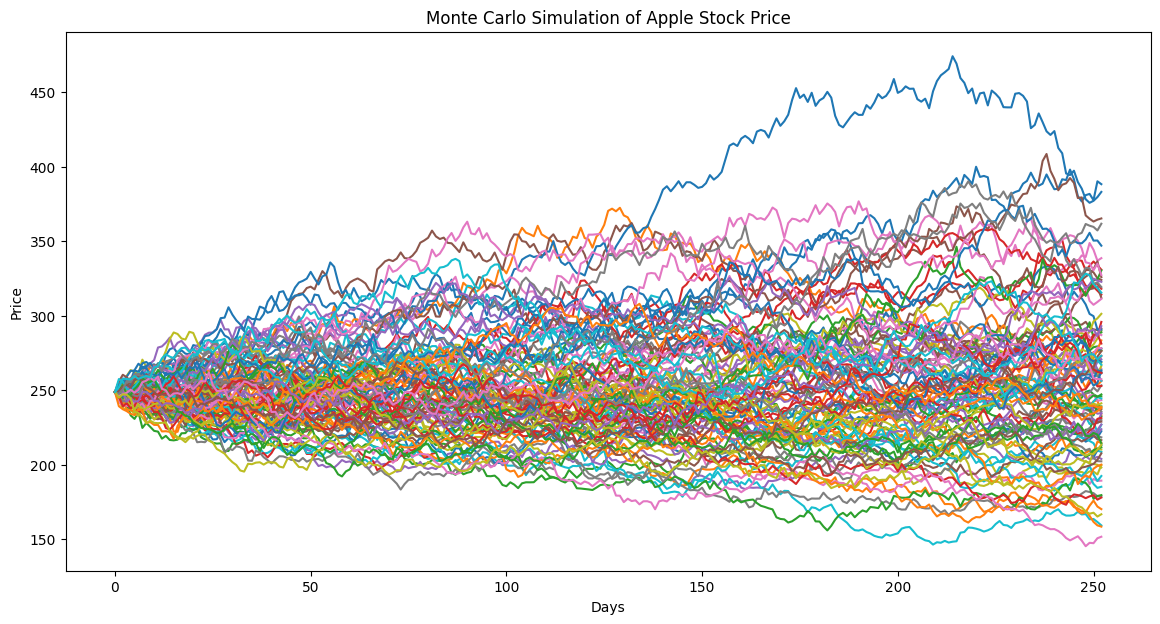

In [7]:
plt.figure(figsize=(14,7))

plt.plot(simulation_df)

plt.title("Monte Carlo Simulation of Apple Stock Price")

plt.xlabel("Days")

plt.ylabel("Price")

plt.show()

In [8]:
final_prices = simulation_df.iloc[-1]

print(final_prices.describe())

count                                                   100
unique                                                  100
top       Ticker
AAPL    222.501086
Name: 2024-12-31 00:...
freq                                                      1
Name: 252, dtype: object


/tmp/ipykernel_617/1947236969.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(final_prices.describe())


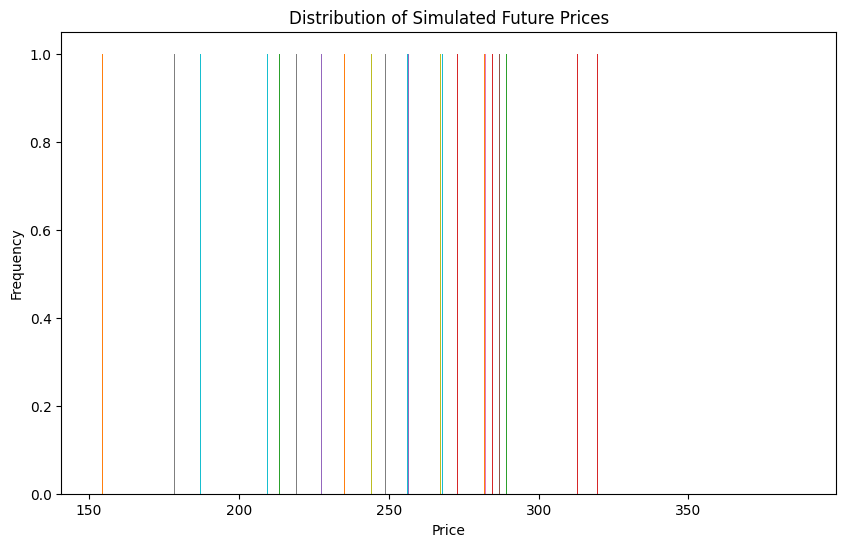

In [9]:
# Distribution of final prices

plt.figure(figsize=(10,6))

plt.hist(final_prices, bins=30)

plt.title("Distribution of Simulated Future Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

# Monte Carlo Stock Price Simulation

## Importing Libraries

## Downloading Stock Data

## Calculating Returns

## Volatility Analysis

## Running Simulations

## Visualizing Future Price Paths